# Event segmentation and onset detection

This notebook implements the event segmentation pipeline for identifying temporal windows in seismic signals. The pipeline consists of:

1. **Crustal velocity estimation** — Average P-wave and S-wave velocities are computed for each station using the CRUST1.0 global model (Laske et al., 2013)
2. **Theoretical arrival times** — P and S wave theoretical arrivals are calculated using epicentral distances and crustal velocities
3. **Signal conversion** — Long-format acceleration DataFrame is converted to nested dictionary structure for efficient processing
4. **Onset detection** — AR-AIC method (ObsPy) detects P and S onsets using all 3 components simultaneously
5. **Temporal windowing** — Four dynamical regimes are defined: pre-arrival, P-wave, S-wave, and coda

The output is a DataFrame with one row per file (66 rows = 22 stations × 3 components) containing detected onset times and window boundaries for moment scaling analysis.

## 1. Imports and visualization settings

In [1]:
import sys
import pandas as pd
import numpy as np
import logging
from matplotlib import pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from IPython.display import display
from src import (
    add_time_columns,
    convert_signals_to_dict,
    validate_signals_dict,
    add_crustal_velocities,
    add_theoretical_arrivals,
    set_plot_style,
    display_theoretical_arrivals_table,
    plot_theoretical_arrivals,
    theoretical_arrivals_to_latex,
    detect_onsets_ar_full_signal,
    plot_onset_detection_results
)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Preprocessed metadata and acceleration signals are loaded from parquet files. The metadata contains 66 rows (22 stations × 3 components), while the signals DataFrame is in long format (one row per sample).

In [2]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01_metadata'
SIGNALS_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '02_signals'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '03_event_segmentation'
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED}")

#Load metadata
logger.info("Loading metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED)
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals
logger.info("Loading acceleration signals...")
df_signals = pd.read_parquet(SIGNALS_PROCESSED)
check(df_signals is not None, "Signals loaded successfully")
check(len(df_signals) > 0, "Signals dataframe is not empty")
logger.info(f"Signals loaded, shape: {df_signals.shape}")
logger.info(f"Unique files: {df_signals['file'].nunique()}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/02_signals
INFO | Loading metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (132, 38)
INFO | Loading acceleration signals...
INFO | Signals loaded successfully
INFO | Signals dataframe is not empty
INFO | Signals loaded, shape: (5229630, 4)
INFO | Unique files: 66


## 3. Metadata preparation

The metadata DataFrame contains 3 rows per station (one for each component: HNE, HNN, HNZ). For crustal velocity estimation and theoretical arrival calculations, we reduce this to 1 row per station, keeping only the essential columns.

In [3]:
logger.info("Preparing station metadata (1 row per station)...")

# Select essential columns and reduce to 1 row per station
df_meta_stations = df_meta.drop_duplicates('STATION_CODE')[[
    'STATION_CODE',
    'STATION_LATITUDE_DEGREE',
    'STATION_LONGITUDE_DEGREE',
    'EPICENTRAL_DISTANCE_KM',
    'INSTRUMENTAL_FREQUENCY_HZ',
    'LOW_CUT_FREQUENCY_HZ',
    'HIGH_CUT_FREQUENCY_HZ',
    'PGA_CM/S^2',
    'TIME_PGA_S',
    'EVENT_DATE',
    'DATE_TIME_FIRST_SAMPLE'
]].copy()

n_stations = len(df_meta_stations)
logger.info(f"Station metadata ready: {n_stations} unique stations")

# Display first rows
print("\nFirst 5 stations:")
display(df_meta_stations.head())

# Summary statistics
print("\nEpicentral distance range:")
print(f"  Min: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].min():.2f} km")
print(f"  Max: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].max():.2f} km")
print(f"  Median: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].median():.2f} km")

INFO | Preparing station metadata (1 row per station)...
INFO | Station metadata ready: 22 unique stations



First 5 stations:


,STATION_CODE,STATION_LATITUDE_DEGREE,STATION_LONGITUDE_DEGREE,EPICENTRAL_DISTANCE_KM,INSTRUMENTAL_FREQUENCY_HZ,LOW_CUT_FREQUENCY_HZ,HIGH_CUT_FREQUENCY_HZ,PGA_CM/S^2,TIME_PGA_S,EVENT_DATE,DATE_TIME_FIRST_SAMPLE
0,EILF,43.547900,7.131200,109.5,200.0,0.5,40.0,0.376358,78.870,2024-12-09 10:41:21,2024-12-09 10:40:40
3,ESCA,43.831000,7.374400,86.5,200.0,0.5,40.0,0.483198,73.185,2024-12-09 10:41:21,2024-12-09 10:40:35
6,ISO,44.184000,7.050000,39.8,200.0,0.4,40.0,0.547306,67.950,2024-12-09 10:41:21,2024-12-09 10:40:26
9,MFC,43.967022,6.919558,60.9,200.0,0.4,40.0,0.339241,71.770,2024-12-09 10:41:21,2024-12-09 10:40:31
12,MON,43.730343,7.424688,98.2,200.0,0.5,20.0,0.114282,75.935,2024-12-09 10:41:21,2024-12-09 10:40:38



Epicentral distance range:
  Min: 4.80 km
  Max: 109.50 km
  Median: 67.80 km


## 4. Crustal velocity estimation

Average P-wave and S-wave velocities are computed for each station location using the CRUST1.0 global crustal model. The model provides velocities for 9 layers (water, ice, 3 sediment layers, 3 crystalline crust layers, mantle) on a 1°×1° grid. We average the velocities across the three crystalline crust layers (upper, middle, lower) to obtain representative crustal velocities.

### References

Laske, G., Masters, G., Ma, Z., & Pasyanos, M. (2013). Update on CRUST1.0 - A 1-degree global model of Earth's crust. *Geophysical Research Abstracts*, 15, EGU2013-2658.

In [4]:
# Add crustal velocities (vp_crust, vs_crust)
df_meta_stations = add_crustal_velocities(
    df_meta_stations,
    lat_col='STATION_LATITUDE_DEGREE',
    lon_col='STATION_LONGITUDE_DEGREE'
)

check('vp_crust' in df_meta_stations.columns, "vp_crust column added")
check('vs_crust' in df_meta_stations.columns, "vs_crust column added")

# Display results
print("\nCrustal velocities (first 5 stations):")
display(df_meta_stations[[
    'STATION_CODE',
    'EPICENTRAL_DISTANCE_KM',
    'vp_crust',
    'vs_crust'
]].head())

INFO | vp_crust column added
INFO | vs_crust column added


Loading CRUST1.0 model...
Querying 22 stations...
Added vp_crust and vs_crust columns
v_P: min=6.33, max=6.73, median=6.33 km/s
v_S: min=3.60, max=3.79, median=3.66 km/s

Crustal velocities (first 5 stations):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,vp_crust,vs_crust
0,EILF,109.5,6.729618,3.789856
3,ESCA,86.5,6.729618,3.789856
6,ISO,39.8,6.331176,3.663886
9,MFC,60.9,6.330868,3.663735
12,MON,98.2,6.729618,3.789856


## 4. Theoretical arrival times

Theoretical P and S wave arrival times are calculated using a simple 1D model:

$$t = t_0 + \frac{d}{v}$$

where $t_0$ is the event origin time (set to 0), $d$ is the epicentral distance, and $v$ is the wave velocity (P or S). These theoretical times provide initial estimates for the onset detection search windows.

In [5]:
logger.info("Calculating theoretical arrival times...")

# Add theoretical arrivals (t_p_theo, t_s_theo)
df_meta_stations = add_theoretical_arrivals(
    df_meta_stations,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('t_p_theo' in df_meta_stations.columns, "t_p_theo column added")
check('t_s_theo' in df_meta_stations.columns, "t_s_theo column added")

# Display results
print("\nTheoretical arrivals (first 5 stations):")
display(df_meta_stations[[
    'STATION_CODE',
    'EPICENTRAL_DISTANCE_KM',
    't_p_theo',
    't_s_theo'
]].head())

# Summary
print("\nTheoretical arrival time ranges:")
print(f"  P-wave: {df_meta_stations['t_p_theo'].min():.2f} - {df_meta_stations['t_p_theo'].max():.2f} s")
print(f"  S-wave: {df_meta_stations['t_s_theo'].min():.2f} - {df_meta_stations['t_s_theo'].max():.2f} s")

INFO | Calculating theoretical arrival times...
INFO | t_p_theo column added
INFO | t_s_theo column added


Added theoretical arrival times
  Origin time range: 5.00 - 55.00 s
  t_P range: 5.76 - 61.29 s
  t_S range: 6.31 - 70.72 s

Theoretical arrivals (first 5 stations):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,t_p_theo,t_s_theo
0,EILF,109.5,57.271354,69.892919
3,ESCA,86.5,58.853627,68.824086
6,ISO,39.8,61.286352,65.862783
9,MFC,60.9,59.619533,66.622380
12,MON,98.2,57.592210,68.911275



Theoretical arrival time ranges:
  P-wave: 5.76 - 61.29 s
  S-wave: 6.31 - 70.72 s


## 5.

In [6]:
logger.info("Adding time column to signals...")
df_signals = add_time_columns(df_signals, df_meta, 
                     time_col='DATE_TIME_FIRST_SAMPLE',
                     sampling_interval_col='SAMPLING_INTERVAL_S')
check('time' in df_signals.columns, "Time column added to signals")

INFO | Adding time column to signals...


Added relative time column (t=0 at first sample)
Sampling interval: 0.005 s (200.0 Hz)
Time range: 0.000 - 279.995 s
Added absolute time column
Time range: 2024-12-09 10:40:26 to 2024-12-09 10:45:09.995000


INFO | Time column added to signals


Duration check: Expected 240.00 s, got 198.09 s


## Visualization

Theoretical Arrival Times Summary

Number of stations: 22

Distance range: 4.8 - 109.5 km
P-wave arrival range: 5.8 - 61.3 s
S-wave arrival range: 6.3 - 70.7 s

Median crustal velocities:
  v_P = 6.33 km/s
  v_S = 3.66 km/s

First 10 stations (sorted by distance):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,vp_crust,vs_crust,t_p_theo,t_s_theo
42,SURF,4.8,6.33,3.66,5.76,6.31
48,BRZ,17.4,6.33,3.66,10.97,12.97
51,CRI,32.0,6.33,3.66,25.09,28.77
18,OGAG,39.4,6.33,3.66,61.22,65.75
6,ISO,39.8,6.33,3.66,61.29,65.86
54,SAV,48.0,6.33,3.66,24.96,30.48
45,BHB,48.4,6.33,3.66,18.72,24.29
57,SLZ,53.5,6.33,3.66,24.49,30.64
39,SPIF,59.3,6.33,3.66,60.37,67.19
9,MFC,60.9,6.33,3.66,59.62,66.62


Figure saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/theoretical_arrivals.pdf


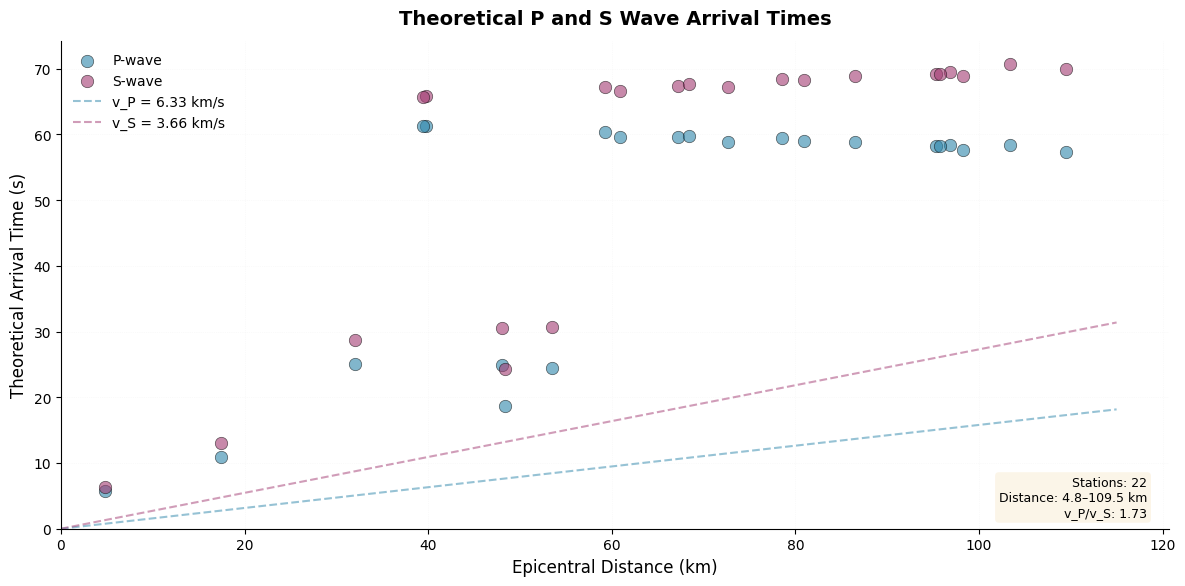

In [7]:
display_theoretical_arrivals_table(df_meta_stations, n_rows=10)

# Plot
fig, ax = plot_theoretical_arrivals(df_meta_stations, 
                                   save_path=FIGURES_DIR / 'theoretical_arrivals.pdf')
plt.show()

In [8]:
latex = theoretical_arrivals_to_latex(
    df_meta_stations,
    output_path=PROJECT_ROOT / 'data' / 'processed' / 'latex_tables' / 'theoretical_arrivals.tex'
)

LaTeX table saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/theoretical_arrivals.tex


## 6. Signal conversion

The acceleration DataFrame in long format (one row per sample) is converted to a nested dictionary structure for efficient access during onset detection:

```python
signals_dict = {
    'SURF': {
        'HNE': array([...]),  # East component
        'HNN': array([...]),  # North component
        'HNZ': array([...]),  # Vertical component
        'time': array([...])  # Time array (shared)
    },
    'BRZ': {...},
    ...
}
```

In [9]:
logger.info("Converting signals to nested dictionary...")

# Convert DataFrame to dict
signals_dict = convert_signals_to_dict(df_signals)

check(len(signals_dict) > 0, "Signals dictionary created")
logger.info(f"Dictionary contains {len(signals_dict)} stations")

# Validate structure
print("\nValidating signals dictionary...")
report = validate_signals_dict(signals_dict)

check(report['valid'], "All signals validated successfully")

INFO | Converting signals to nested dictionary...


Converting 66 files to nested dictionary...


INFO | Signals dictionary created
INFO | Dictionary contains 22 stations
INFO | All signals validated successfully


Converted 66 files
Stations: 22
Components per station: {3}

Validating signals dictionary...
All 22 stations validated


Running AR-AIC onset detection on 22 stations...
Processing: ...................... Done!

Detection summary:
  Successful: 2 / 22 (9.1%)

P-wave residuals (detected - theoretical):
  Mean: +21.10 s
  Std:  10.77 s
  Range: [+13.48, +28.71] s

S-wave residuals (detected - theoretical):
  Mean: +27.11 s
  Std:  13.24 s
  Range: [+17.75, +36.47] s

Failed detections:
  EILF: Incomplete components: Z=HNZ, N=HNN, E=None
  ESCA: Incomplete components: Z=HNZ, N=HNN, E=None
  ISO: Incomplete components: Z=HNZ, N=HNN, E=None
  MFC: Incomplete components: Z=HNZ, N=HNN, E=None
  MON: Incomplete components: Z=HNZ, N=HNN, E=None
  MVIF: Incomplete components: Z=HNZ, N=HNN, E=None
  OGAG: Incomplete components: Z=HNZ, N=HNN, E=None
  OGDI: Incomplete components: Z=HNZ, N=HNN, E=None
  OGMO: Incomplete components: Z=HNZ, N=HNN, E=None
  OGS3: Incomplete components: Z=HNZ, N=HNN, E=None
  OGSA: Incomplete components: Z=HNZ, N=HNN, E=None
  REVF: Incomplete components: Z=HNZ, N=HN2, E=None
  SAOF: Inc

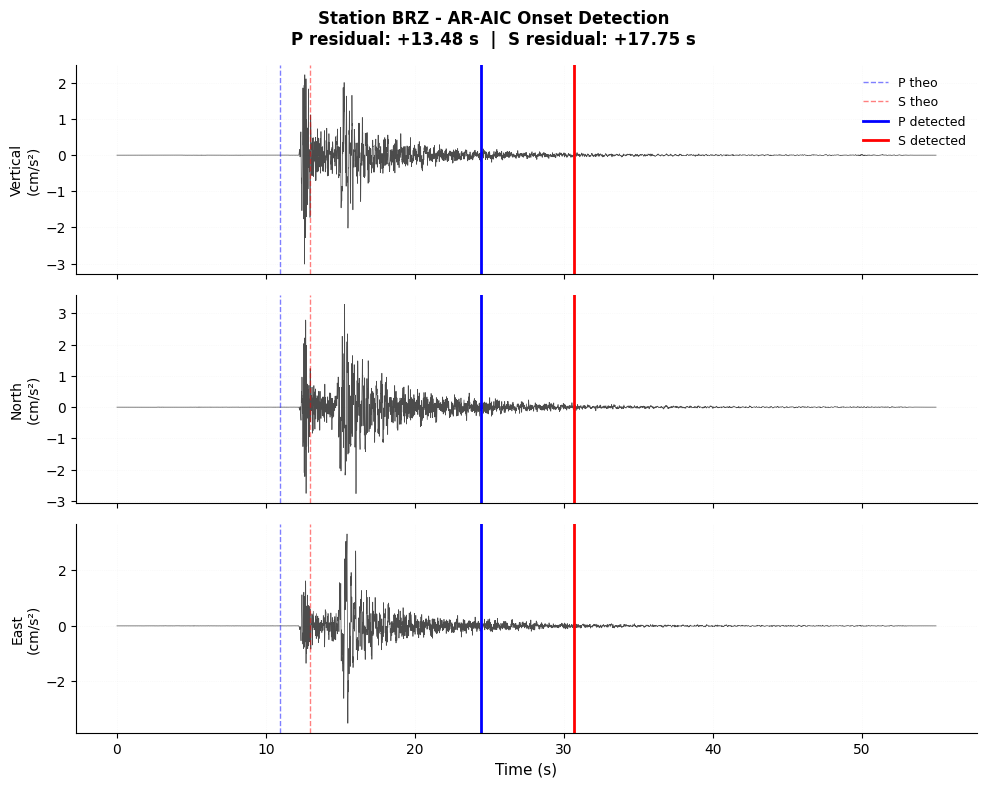

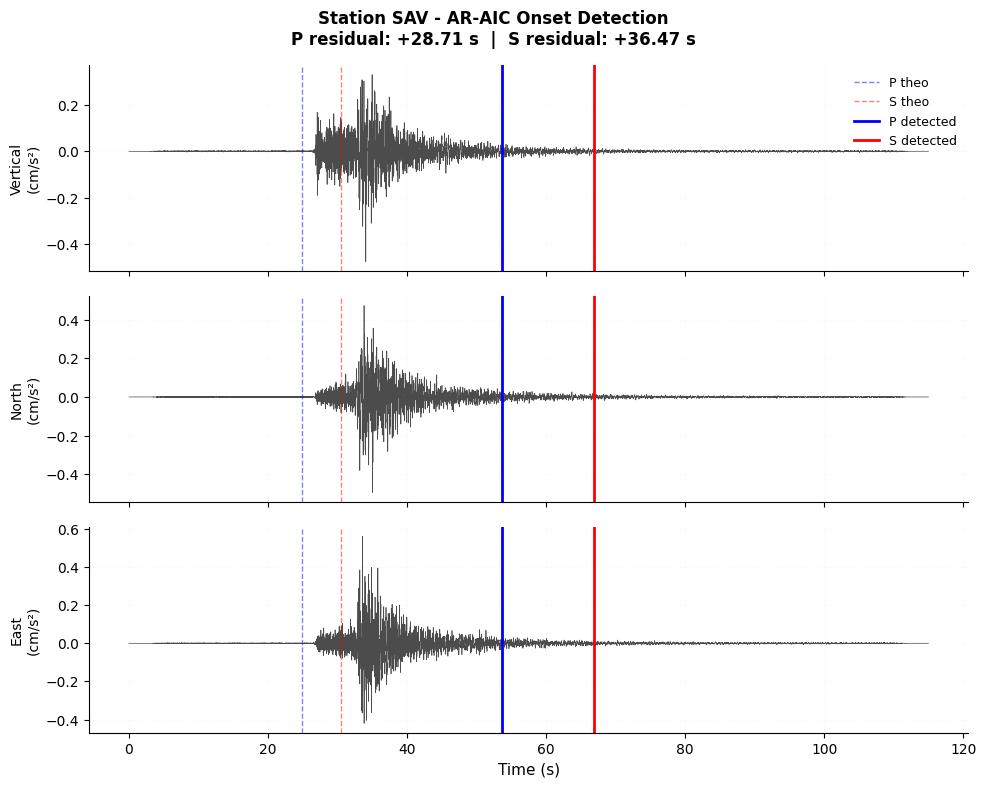

In [10]:
# Detect onsets on full signal
df_onset_results = detect_onsets_ar_full_signal(signals_dict, df_meta_stations)

# Plot results (all stations)
figures = plot_onset_detection_results(
    signals_dict, 
    df_onset_results,
    save_dir=FIGURES_DIR / 'onset_detection_full_signal'
)

plt.show()

# Or plot only specific stations
figures_subset = plot_onset_detection_results(
    signals_dict, 
    df_onset_results,
    stations=['EILF', 'SURF', 'ISO'],
    save_dir=None  # Don't save
)
plt.show()